# BÀI TẬP LỚN CUỐI KHÓA — CSE703185
## Lập trình cho Phân tích Dữ liệu
### Trường Đại học Phenikaa

**Kịch bản:** Phân tích dữ liệu kinh doanh cho Công ty Phenikaa Commerce (B2B E-commerce)

---

---
# PHẦN 1: NỀN TẢNG LẬP TRÌNH PYTHON (20 điểm)
**CĐR 1.1** — Biến, Kiểu dữ liệu, Điều kiện, Vòng lặp, List, Dict, Set, Tuple, Hàm

## 1.1 Tạo và xử lý dữ liệu thô bằng cấu trúc Python thuần (5 điểm)

In [5]:
import random
from datetime import datetime, timedelta

random.seed(42)

# Danh sách hằng số dùng để sinh dữ liệu
KHU_VUC    = ["HN", "HCM", "DN", "CT", "HP"]
KENH_BAN   = ["Zalo", "Facebook", "Website", "Email", "Telesales"]
DANH_MUC   = ["Dien tu", "Van phong pham", "Thuc pham", "May mac", "Do gia dung"]
TRANG_THAI = ["done", "pending", "cancel"]

def _random_date(start_year=2024):
    start = datetime(start_year, 1, 1)
    return (start + timedelta(days=random.randint(0, 549))).strftime("%Y-%m-%d")

# LIST: danh sach don hang (>= 20 ban ghi)
don_hang_list = []

for i in range(20):
    # Tạo mã đơn hàng (ví dụ: ORD0001, ORD0002...)
    ma = "ORD" + str(i + 1).zfill(4)
    ngay = _random_date()
    kv = random.choice(KHU_VUC)
    kenh = random.choice(KENH_BAN)
    danh_muc = random.choice(DANH_MUC)
    
    # Giá trị ngẫu nhiên từ 1 triệu đến 30 triệu
    gia_tri = random.randint(1_000_000, 30_000_000)
    
    # Sử dụng Điều kiện (if-else) đơn giản để phân loại trạng thái hoặc giá trị nếu cần
    trang_thai = random.choice(TRANG_THAI)

    # Mỗi đơn hàng là một DICT chứa thông tin chi tiết
    mot_don_hang = {
        "ma_don": ma,
        "ngay_dat": ngay,
        "khu_vuc": kv,
        "kenh_ban": kenh,
        "danh_muc": danh_muc,
        "gia_tri": gia_tri,
        "trang_thai": trang_thai
    }
    
    # Thêm vào danh sách List
    don_hang_list.append(mot_don_hang)

# DICT: tra cuu nhanh don hang theo ma
don_hang_dict = {dh["ma_don"]: dh for dh in don_hang_list}

# SET: tap hop cac khu vuc thuc su co don
khu_vuc_co_don = {dh["khu_vuc"] for dh in don_hang_list}

# TUPLE: nguong phan khuc bat bien (Nho / Trung / Lon)
NGUONG_PHAN_KHUC = (5_000_000, 20_000_000)

print(f"So don hang       : {len(don_hang_list)}")
print(f"Khu vuc co don    : {khu_vuc_co_don}")
print(f"Nguong phan khuc  : {NGUONG_PHAN_KHUC}")
print("\n5 don dau tien:")
for dh in don_hang_list[:5]:
    print(f"  {dh['ma_don']} | {dh['ngay_dat']} | {dh['khu_vuc']:3s} | "
          f"{dh['kenh_ban']:10s} | {dh['gia_tri']:>15,.0f} VND | {dh['trang_thai']}")


So don hang       : 20
Khu vuc co don    : {'DN', 'HN', 'CT', 'HP', 'HCM'}
Nguong phan khuc  : (5000000, 20000000)

5 don dau tien:
  ORD0001 | 2024-04-24 | HN  | Website    |       8,489,709 VND | done
  ORD0002 | 2024-04-14 | HP  | Zalo       |      15,157,347 VND | done
  ORD0003 | 2024-01-31 | HN  | Facebook   |      17,956,909 VND | cancel
  ORD0004 | 2024-01-28 | HP  | Facebook   |      15,076,749 VND | done
  ORD0005 | 2025-04-04 | HP  | Website    |      26,461,350 VND | done


## 1.2 Xây dựng hàm xử lý và thống kê dữ liệu (10 điểm)

In [6]:
def loc_don_hang(ds, **tieu_chi):
    """Loc don hang theo nhieu tieu chi tuy y.

    Args:
        ds (list[dict]): Danh sach don hang.
        **tieu_chi: Cac tieu chi loc dang key=value.

    Returns:
        list[dict]: Danh sach don hang thoa tat ca tieu chi.

    Example:
        >>> loc_don_hang(ds, khu_vuc="HN", trang_thai="done")
    """
    ket_qua = ds
    for truong, gia_tri in tieu_chi.items():
        ket_qua = [dh for dh in ket_qua if dh.get(truong) == gia_tri]
    return ket_qua


def thong_ke_theo_nhom(ds, truong_nhom):
    """Tong hop du lieu theo mot truong phan loai.

    Args:
        ds (list[dict]): Danh sach don hang.
        truong_nhom (str): Ten truong dung de nhom (vd: 'khu_vuc').

    Returns:
        dict: {nhom: {so_don, tong_gia_tri, gia_tri_tb, ty_le_hoan_thanh}}
    """
    thong_ke = {}
    for dh in ds:
        nhom = dh[truong_nhom]
        if nhom not in thong_ke:
            thong_ke[nhom] = {"so_don": 0, "tong_gia_tri": 0, "so_done": 0}
        thong_ke[nhom]["so_don"]       += 1
        thong_ke[nhom]["tong_gia_tri"] += dh["gia_tri"]
        if dh["trang_thai"] == "done":
            thong_ke[nhom]["so_done"] += 1

    ket_qua = {}
    for nhom, data in thong_ke.items():
        so_don = data["so_don"]
        ket_qua[nhom] = {
            "so_don"           : so_don,
            "tong_gia_tri"     : data["tong_gia_tri"],
            "gia_tri_tb"       : data["tong_gia_tri"] / so_don,
            "ty_le_hoan_thanh" : round(data["so_done"] / so_don * 100, 1),
        }
    return ket_qua


def phan_khuc_don_hang(ds):
    """Phan loai don hang thanh 3 muc theo gia_tri.

    Args:
        ds (list[dict]): Danh sach don hang.

    Returns:
        list[dict]: Ban sao co them truong 'phan_khuc'.

    Note:
        Nguong dung NGUONG_PHAN_KHUC = (5_000_000, 20_000_000):
        - Nho  : gia_tri <  5 trieu
        - Trung: 5 trieu <= gia_tri < 20 trieu
        - Lon  : gia_tri >= 20 trieu
    """
    nho, lon = NGUONG_PHAN_KHUC
    ket_qua = []
    for dh in ds:
        ban_sao = dict(dh)
        gv = dh["gia_tri"]
        if gv < nho:
            ban_sao["phan_khuc"] = "Nho"
        elif gv < lon:
            ban_sao["phan_khuc"] = "Trung"
        else:
            ban_sao["phan_khuc"] = "Lon"
        ket_qua.append(ban_sao)
    return ket_qua


def bao_cao_tom_tat(ds):
    """In Executive Summary ra man hinh.

    Args:
        ds (list[dict]): Danh sach don hang.
    """
    tong_doanh_thu = sum(dh["gia_tri"] for dh in ds)
    so_don         = len(ds)
    so_done        = sum(1 for dh in ds if dh["trang_thai"] == "done")
    tk_kenh        = thong_ke_theo_nhom(ds, "kenh_ban")
    top_kenh       = max(tk_kenh, key=lambda k: tk_kenh[k]["tong_gia_tri"])
    tk_kv          = thong_ke_theo_nhom(ds, "khu_vuc")
    top_kv         = max(tk_kv, key=lambda k: tk_kv[k]["so_don"])

    print("=" * 55)
    print("     EXECUTIVE SUMMARY -- PHENIKAA COMMERCE")
    print("=" * 55)
    print(f"  Tong doanh thu     : {tong_doanh_thu:>18,.0f} VND")
    print(f"  Tong so don        : {so_don:>18,}")
    print(f"  Don hoan thanh     : {so_done:>18,}  ({so_done/so_don*100:.1f}%)")
    print(f"  AOV (gia tri TB)   : {tong_doanh_thu/so_don:>18,.0f} VND")
    print(f"  Top kenh ban hang  : {top_kenh:>18s}")
    print(f"  Top khu vuc        : {top_kv:>18s}")
    print("=" * 55)


# Kiem tra cac ham
print(">>> loc_don_hang(khu_vuc='HN', trang_thai='done'):")
hn_done = loc_don_hang(don_hang_list, khu_vuc="HN", trang_thai="done")
for dh in hn_done:
    print(f"    {dh['ma_don']} | {dh['gia_tri']:,.0f} VND")

print()
print(">>> thong_ke_theo_nhom(kenh_ban):")
tk_kenh = thong_ke_theo_nhom(don_hang_list, "kenh_ban")
for k, v in sorted(tk_kenh.items(), key=lambda x: -x[1]["tong_gia_tri"]):
    print(f"    {k:12s}: {v['so_don']} don | "
          f"{v['tong_gia_tri']:>15,.0f} VND | HT: {v['ty_le_hoan_thanh']}%")

print()
print(">>> phan_khuc_don_hang():")
ds_phan_khuc = phan_khuc_don_hang(don_hang_list)
for pk in ["Nho", "Trung", "Lon"]:
    so = sum(1 for d in ds_phan_khuc if d["phan_khuc"] == pk)
    print(f"    {pk:6s}: {so} don")

print()
bao_cao_tom_tat(don_hang_list)


>>> loc_don_hang(khu_vuc='HN', trang_thai='done'):
    ORD0001 | 8,489,709 VND

>>> thong_ke_theo_nhom(kenh_ban):
    Website     : 6 don |      89,199,172 VND | HT: 33.3%
    Zalo        : 4 don |      80,999,581 VND | HT: 50.0%
    Email       : 5 don |      65,263,950 VND | HT: 0.0%
    Facebook    : 3 don |      59,031,340 VND | HT: 33.3%
    Telesales   : 2 don |      22,973,173 VND | HT: 50.0%

>>> phan_khuc_don_hang():
    Nho   : 1 don
    Trung : 13 don
    Lon   : 6 don

     EXECUTIVE SUMMARY -- PHENIKAA COMMERCE
  Tong doanh thu     :        317,467,216 VND
  Tong so don        :                 20
  Don hoan thanh     :                  6  (30.0%)
  AOV (gia tri TB)   :         15,873,361 VND
  Top kenh ban hang  :            Website
  Top khu vuc        :                 HN


## 1.3 Lambda, Filter, Map, Sorted nâng cao (5 điểm)

In [7]:
# (1) filter(): Loc don hang da hoan thanh
# Muc dich: Lay danh sach don "done" de tinh doanh thu thuc te
don_hoan_thanh = list(filter(lambda dh: dh["trang_thai"] == "done", don_hang_list))
print(f"[filter] So don hoan thanh: {len(don_hoan_thanh)}")

# (2) map(): Tinh doanh thu sau chiet khau 5% cho don "done"
# Muc dich: Phan anh doanh thu thuc nhan (sau CK dai ly 5%)
CHIET_KHAU = 0.05
dt_sau_ck = list(map(
    lambda dh: dh["gia_tri"] * (1 - CHIET_KHAU),
    don_hoan_thanh
))
print(f"[map]    Tong DT sau chiet khau: {sum(dt_sau_ck):,.0f} VND")

# (3) sorted() voi key=lambda: Xep don theo gia tri giam dan
# Muc dich: Nhanh chong tim cac don lon nhat de uu tien xu ly
don_sap_xep = sorted(don_hang_list, key=lambda dh: dh["gia_tri"], reverse=True)
print("\n[sorted] Top 5 don hang lon nhat:")
for dh in don_sap_xep[:5]:
    print(f"    {dh['ma_don']} | {dh['gia_tri']:>15,.0f} VND | {dh['trang_thai']}")

# (4) List comprehension voi dieu kien: don lon chua hoan thanh
# Muc dich: Phat hien don lon (> 20 trieu) can theo doi dac biet
NGUONG_THEO_DOI = 20_000_000
don_can_theo_doi = [
    dh["ma_don"]
    for dh in don_hang_list
    if dh["gia_tri"] > NGUONG_THEO_DOI and dh["trang_thai"] != "done"
]
print(f"\n[list comprehension] Don > 20tr chua hoan thanh: {don_can_theo_doi}")


[filter] So don hoan thanh: 6
[map]    Tong DT sau chiet khau: 92,920,153 VND

[sorted] Top 5 don hang lon nhat:
    ORD0009 |      29,914,085 VND | pending
    ORD0015 |      28,575,119 VND | done
    ORD0010 |      26,939,869 VND | pending
    ORD0005 |      26,461,350 VND | done
    ORD0018 |      25,997,682 VND | cancel

[list comprehension] Don > 20tr chua hoan thanh: ['ORD0009', 'ORD0010', 'ORD0017', 'ORD0018']


---
# PHẦN 2: LẬP TRÌNH HƯỚNG ĐỐI TƯỢNG (20 điểm)
**CĐR 1.1** — Class, `__init__`, `@property`, Kế thừa, Đa hình, `__str__`

## 2.1 Thiết kế phân cấp lớp cho hệ thống (10 điểm)

In [8]:
import re

class KhachHang:
    """Lop co so dai dien cho khach hang cua Phenikaa Commerce.

    Attributes:
        ma_kh (str): Ma khach hang duy nhat.
        ho_ten (str): Ho va ten.
        _email (str): Email (private, truy cap qua @property).
        dia_chi (str): Dia chi.
        ngay_dang_ky (str): Ngay dang ky tai khoan (YYYY-MM-DD).
    """

    def __init__(self, ma_kh: str, ho_ten: str, email: str,
                 dia_chi: str, ngay_dang_ky: str):
        self.ma_kh        = ma_kh
        self.ho_ten       = ho_ten
        self.email        = email
        self.dia_chi      = dia_chi
        self.ngay_dang_ky = ngay_dang_ky

    @property
    def email(self) -> str:
        return self._email

    @email.setter
    def email(self, gia_tri: str):
        if not re.match(r"^[\w.+-]+@[\w-]+\.[\w.]{2,}$", gia_tri):
            raise ValueError(f"Email khong hop le: '{gia_tri}'")
        self._email = gia_tri

    def lich_su_mua_hang(self, ds_don: list) -> list:
        """Loc don hang thuoc ve khach hang nay.

        Args:
            ds_don (list[dict]): Toan bo danh sach don hang.

        Returns:
            list[dict]: Cac don co ma_kh trung khop.
        """
        return [d for d in ds_don if d.get("ma_kh") == self.ma_kh]

    def __str__(self) -> str:
        return (f"KhachHang({self.ma_kh}) | {self.ho_ten} "
                f"| {self.email} | {self.dia_chi}")

    def __lt__(self, other) -> bool:
        # So sanh theo ma khach hang (dung cho sorted())
        return self.ma_kh < other.ma_kh

    def __eq__(self, other: object) -> bool:
        if not isinstance(other, KhachHang):
            return NotImplemented
        return self.ma_kh == other.ma_kh


class KhachHangVIP(KhachHang):
    """Khach hang VIP -- ke thua KhachHang, them hang va diem tich luy.

    Attributes:
        hang_vip (str): 'Silver', 'Gold' hoac 'Platinum'.
        diem_tich_luy (int): Diem tich luy tu cac don hang.
    """

    UU_DAI = {"Silver": 0.05, "Gold": 0.10, "Platinum": 0.15}

    def __init__(self, ma_kh: str, ho_ten: str, email: str,
                 dia_chi: str, ngay_dang_ky: str,
                 hang_vip: str = "Silver", diem_tich_luy: int = 0):
        super().__init__(ma_kh, ho_ten, email, dia_chi, ngay_dang_ky)
        if hang_vip not in self.UU_DAI:
            raise ValueError(f"Hang VIP khong hop le: {hang_vip}")
        self.hang_vip      = hang_vip
        self.diem_tich_luy = diem_tich_luy

    def tinh_uu_dai(self) -> float:
        """Tinh phan tram giam gia theo hang VIP.

        Returns:
            float: Ti le giam gia (0.05 / 0.10 / 0.15).
        """
        return self.UU_DAI[self.hang_vip]

    def __str__(self) -> str:
        base = super().__str__()
        return (f"{base} | VIP {self.hang_vip} "
                f"| Diem: {self.diem_tich_luy:,} "
                f"| Uu dai: {self.tinh_uu_dai()*100:.0f}%")


class SanPham:
    """San pham trong kho cua Phenikaa Commerce.

    Attributes:
        ma_sp (str): Ma san pham.
        ten (str): Ten san pham.
        danh_muc (str): Danh muc.
        gia (float): Gia ban (VND).
        ton_kho (int): So luong ton kho.
        muc_canh_bao (int): Nguong canh bao can nhap hang.
    """

    THUE_VAT = 0.10

    def __init__(self, ma_sp: str, ten: str, danh_muc: str,
                 gia: float, ton_kho: int, muc_canh_bao: int = 10):
        self.ma_sp        = ma_sp
        self.ten          = ten
        self.danh_muc     = danh_muc
        self.gia          = gia
        self.ton_kho      = ton_kho
        self.muc_canh_bao = muc_canh_bao

    def can_nhap_hang(self) -> bool:
        """Kiem tra co can nhap hang khong.

        Returns:
            bool: True neu ton kho <= muc canh bao.
        """
        return self.ton_kho <= self.muc_canh_bao

    def tinh_gia_sau_thue(self) -> float:
        """Tinh gia ban da bao gom VAT 10%.

        Returns:
            float: Gia sau thue.
        """
        return self.gia * (1 + self.THUE_VAT)

    def __repr__(self) -> str:
        canh_bao = " [!] CAN NHAP HANG" if self.can_nhap_hang() else ""
        return (f"SanPham({self.ma_sp}) | {self.ten} "
                f"| {self.danh_muc} | {self.gia:,.0f} VND "
                f"| Ton: {self.ton_kho}{canh_bao}")

    def __lt__(self, other) -> bool:
        return self.gia < other.gia


print("OK Dinh nghia 3 lop thanh cong: KhachHang, KhachHangVIP, SanPham")


OK Dinh nghia 3 lop thanh cong: KhachHang, KhachHangVIP, SanPham


## 2.2 Tích hợp và kiểm thử hệ thống lớp (10 điểm)

In [9]:
# Tao cac doi tuong
kh1 = KhachHang(
    "KH001", "Nguyen Van An", "an.nguyen@company.vn",
    "Ha Noi", "2023-01-15"
)
kh2 = KhachHang(
    "KH002", "Tran Thi Binh", "binh.tran@corp.com",
    "TP.HCM", "2023-03-20"
)
kh3 = KhachHangVIP(
    "KH003", "Le Minh Cuong", "cuong.le@enterprise.vn",
    "Da Nang", "2022-06-01", hang_vip="Gold", diem_tich_luy=4_500
)
kh4 = KhachHangVIP(
    "KH004", "Pham Hai Duong", "duong.pham@bigcorp.vn",
    "Hai Phong", "2021-09-10", hang_vip="Platinum", diem_tich_luy=12_000
)
kh5 = KhachHangVIP(
    "KH005", "Hoang Thi Em", "em.hoang@sme.com",
    "Can Tho", "2023-11-05", hang_vip="Silver", diem_tich_luy=800
)

sp1 = SanPham("SP001", "Laptop Dell Latitude", "Dien tu",        25_000_000, 5,   10)
sp2 = SanPham("SP002", "Giay A4 Double A",     "Van phong pham",    85_000, 150,  20)
sp3 = SanPham("SP003", "May in HP LaserJet",   "Dien tu",         8_500_000, 3,   5)

ds_kh = [kh1, kh2, kh3, kh4, kh5]
ds_sp = [sp1, sp2, sp3]

# (a) sorted() tan dung __lt__
print("(a) Khach hang sap xep theo ma:")
for kh in sorted(ds_kh):
    print(f"    {kh}")

# (b) isinstance() phan loai doi tuong
print("\n(b) Phan loai doi tuong:")
for kh in ds_kh:
    loai = "KhachHangVIP" if isinstance(kh, KhachHangVIP) else "KhachHang thuong"
    print(f"    {kh.ma_kh} -- {loai}")

# (c) Goi du tat ca phuong thuc
print("\n(c) Kiem tra phuong thuc:")
print(f"    lich_su_mua_hang(kh1): {kh1.lich_su_mua_hang(don_hang_list)}")
print(f"    tinh_uu_dai(kh3 Gold): {kh3.tinh_uu_dai()*100:.0f}%")
print(f"    tinh_uu_dai(kh4 Plat): {kh4.tinh_uu_dai()*100:.0f}%")
print(f"    can_nhap_hang(sp1 Ton={sp1.ton_kho}): {sp1.can_nhap_hang()}")
print(f"    can_nhap_hang(sp2 Ton={sp2.ton_kho}): {sp2.can_nhap_hang()}")
print(f"    tinh_gia_sau_thue(sp3): {sp3.tinh_gia_sau_thue():,.0f} VND")
print("\n    San pham sap xep theo gia:")
for sp in sorted(ds_sp):
    print(f"    {repr(sp)}")

# (d) try-except: gan email sai dinh dang
print("\n(d) Xu ly loi email sai dinh dang:")
try:
    kh1.email = "email-khong-hop-le"
except ValueError as e:
    print(f"    ERROR bat duoc: {e}")
    print(f"    Email kh1 van giu nguyen: {kh1.email}")


(a) Khach hang sap xep theo ma:
    KhachHang(KH001) | Nguyen Van An | an.nguyen@company.vn | Ha Noi
    KhachHang(KH002) | Tran Thi Binh | binh.tran@corp.com | TP.HCM
    KhachHang(KH003) | Le Minh Cuong | cuong.le@enterprise.vn | Da Nang | VIP Gold | Diem: 4,500 | Uu dai: 10%
    KhachHang(KH004) | Pham Hai Duong | duong.pham@bigcorp.vn | Hai Phong | VIP Platinum | Diem: 12,000 | Uu dai: 15%
    KhachHang(KH005) | Hoang Thi Em | em.hoang@sme.com | Can Tho | VIP Silver | Diem: 800 | Uu dai: 5%

(b) Phan loai doi tuong:
    KH001 -- KhachHang thuong
    KH002 -- KhachHang thuong
    KH003 -- KhachHangVIP
    KH004 -- KhachHangVIP
    KH005 -- KhachHangVIP

(c) Kiem tra phuong thuc:
    lich_su_mua_hang(kh1): []
    tinh_uu_dai(kh3 Gold): 10%
    tinh_uu_dai(kh4 Plat): 15%
    can_nhap_hang(sp1 Ton=5): True
    can_nhap_hang(sp2 Ton=150): False
    tinh_gia_sau_thue(sp3): 9,350,000 VND

    San pham sap xep theo gia:
    SanPham(SP002) | Giay A4 Double A | Van phong pham | 85,000 VND | 

---
# PHẦN 3: XỬ LÝ DỮ LIỆU VỚI NUMPY & PANDAS (25 điểm)
**CĐR 1.1 + 2.1** — ndarray, vectorization, DataFrame, EDA, groupby, pivot_table

## 3.1 Tạo và kiểm tra dữ liệu (5 điểm)

In [10]:
import numpy as np
import pandas as pd

np.random.seed(42)
N = 350  # >= 300 ban ghi

# Tao du lieu mo phong bang NumPy
khu_vuc_arr    = np.random.choice(["HN", "HCM", "DN", "CT", "HP"], N)
kenh_ban_arr   = np.random.choice(
    ["Zalo", "Facebook", "Website", "Email", "Telesales"], N,
    p=[0.15, 0.25, 0.30, 0.20, 0.10]
)
danh_muc_arr   = np.random.choice(
    ["Dien tu", "Van phong pham", "Thuc pham", "May mac", "Do gia dung"], N
)
trang_thai_arr = np.random.choice(
    ["done", "pending", "cancel"], N, p=[0.60, 0.25, 0.15]
)

# Gia tri don hang -- phan phoi log-normal gan thuc te B2B
gia_tri_arr  = np.round(
    np.random.lognormal(mean=15.5, sigma=1.0, size=N) / 1000 * 1000, -3
)
chiet_khau_arr = np.round(np.random.uniform(0, 0.15, N), 2)

# Ngay dat hang: 2024-01-01 --> 2025-06-30
ngay_bat_dau = np.datetime64("2024-01-01")
ngay_dat_arr = ngay_bat_dau + np.random.randint(0, 547, N).astype("timedelta64[D]")

# Tao DataFrame
df_orders = pd.DataFrame({
    "ma_don"     : [f"ORD{str(i+1).zfill(5)}" for i in range(N)],
    "ngay_dat"   : pd.to_datetime(ngay_dat_arr),
    "khu_vuc"    : khu_vuc_arr,
    "kenh_ban"   : kenh_ban_arr,
    "danh_muc"   : danh_muc_arr,
    "gia_tri"    : gia_tri_arr,
    "chiet_khau" : chiet_khau_arr,
    "trang_thai" : trang_thai_arr,
})

df_orders["thang"] = df_orders["ngay_dat"].dt.to_period("M")
df_orders["quy"]   = df_orders["ngay_dat"].dt.quarter

# Them NaN va duplicate nhan tao de thuc hanh lam sach
idx_nan = np.random.choice(N, 10, replace=False)
df_orders.loc[idx_nan, "gia_tri"] = np.nan
df_orders = pd.concat([df_orders, df_orders.iloc[:5]], ignore_index=True)

print("=== TRANG THAI DU LIEU TRUOC KHI LAM SACH ===")
print(f"So ban ghi   : {len(df_orders)}")
print(f"So cot       : {df_orders.shape[1]}")
print("\nGia tri NaN moi cot:")
print(df_orders.isnull().sum()[df_orders.isnull().sum() > 0])
print(f"\nSo hang trung lap: {df_orders.duplicated().sum()}")

# Lam sach du lieu
df_orders.drop_duplicates(inplace=True)
df_orders.reset_index(drop=True, inplace=True)

median_gia_tri = df_orders["gia_tri"].median()
df_orders["gia_tri"].fillna(median_gia_tri, inplace=True)

Q1  = df_orders["gia_tri"].quantile(0.25)
Q3  = df_orders["gia_tri"].quantile(0.75)
IQR = Q3 - Q1
so_outlier = ((df_orders["gia_tri"] < Q1 - 1.5*IQR) |
              (df_orders["gia_tri"] > Q3 + 1.5*IQR)).sum()

print("\n=== TRANG THAI SAU KHI LAM SACH ===")
print(f"So ban ghi   : {len(df_orders)}")
print(f"NaN con lai  : {df_orders.isnull().sum().sum()}")
print(f"Hang trung   : {df_orders.duplicated().sum()}")
print(f"Outlier IQR  : {so_outlier} ban ghi")
print(f"\nVung IQR: [{Q1:,.0f} ; {Q3:,.0f}] VND  |  Trung vi: {median_gia_tri:,.0f} VND")
print("\n5 ban ghi dau:")
print(df_orders.head())


=== TRANG THAI DU LIEU TRUOC KHI LAM SACH ===
So ban ghi   : 355
So cot       : 10

Gia tri NaN moi cot:
gia_tri    11
dtype: int64

So hang trung lap: 5

=== TRANG THAI SAU KHI LAM SACH ===
So ban ghi   : 350
NaN con lai  : 0
Hang trung   : 0
Outlier IQR  : 32 ban ghi

Vung IQR: [3,019,000 ; 10,858,000] VND  |  Trung vi: 5,825,500 VND

5 ban ghi dau:
     ma_don   ngay_dat khu_vuc  kenh_ban        danh_muc     gia_tri  \
0  ORD00001 2024-08-30      CT     Email     Do gia dung   5370000.0   
1  ORD00002 2024-02-01      HP     Email         May mac   5825500.0   
2  ORD00003 2025-01-25      DN  Facebook  Van phong pham  24237000.0   
3  ORD00004 2024-10-03      HP      Zalo         Dien tu  12960000.0   
4  ORD00005 2025-06-15      HP  Facebook         Dien tu   4321000.0   

   chiet_khau trang_thai    thang  quy  
0        0.01    pending  2024-08    3  
1        0.15       done  2024-02    1  
2        0.01       done  2025-01    1  
3        0.10    pending  2024-10    4  
4       

C:\Users\PC\AppData\Local\Temp\ipykernel_5596\3619357955.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_orders["gia_tri"].fillna(median_gia_tri, inplace=True)


## 3.2 Phân tích dữ liệu đa chiều (15 điểm)

In [11]:
# (a) Thong ke mo ta
print("(a) THONG KE MO TA CAC COT SO")
print(df_orders[["gia_tri", "chiet_khau"]].describe().round(2))
print("""
Nhan xet phan phoi:
  - gia_tri: Phan phoi lech phai (mean >> median) -- dac trung du lieu B2B
    voi mot so don hang lon keo trung binh len cao.
  - chiet_khau: Phan phoi gan deu [0, 0.15] -- chinh sach CK linh hoat theo don.
""")


(a) THONG KE MO TA CAC COT SO
           gia_tri  chiet_khau
count       350.00      350.00
mean    9483302.86        0.07
std    10815616.80        0.04
min      298000.00        0.00
25%     3019000.00        0.04
50%     5825500.00        0.08
75%    10858000.00        0.11
max    71108000.00        0.15

Nhan xet phan phoi:
  - gia_tri: Phan phoi lech phai (mean >> median) -- dac trung du lieu B2B
    voi mot so don hang lon keo trung binh len cao.
  - chiet_khau: Phan phoi gan deu [0, 0.15] -- chinh sach CK linh hoat theo don.



In [12]:
# (b) Phan tich kenh ban hang
print("(b) PHAN TICH KENH BAN HANG")

df_done_kenh = df_orders[df_orders["trang_thai"] == "done"]

tk_kenh = (
    df_orders.groupby("kenh_ban")
    .agg(
        so_don        =("ma_don",  "count"),
        tong_dt       =("gia_tri", "sum"),
        dt_trung_binh =("gia_tri", "mean"),
    )
)
tk_kenh["ty_le_hoan_thanh_pct"] = (
    df_done_kenh.groupby("kenh_ban")["ma_don"].count()
    .reindex(tk_kenh.index, fill_value=0) / tk_kenh["so_don"] * 100
).round(1)

tk_kenh["dt_tb_don_done"] = (
    df_done_kenh.groupby("kenh_ban")["gia_tri"].mean()
    .reindex(tk_kenh.index, fill_value=0)
).round(0)

tk_kenh = tk_kenh.sort_values("tong_dt", ascending=False)

disp = tk_kenh.copy()
disp["tong_dt"]        = disp["tong_dt"].map("{:,.0f}".format)
disp["dt_trung_binh"]  = disp["dt_trung_binh"].map("{:,.0f}".format)
disp["dt_tb_don_done"] = disp["dt_tb_don_done"].map("{:,.0f}".format)
print(disp.to_string())


(b) PHAN TICH KENH BAN HANG
           so_don        tong_dt dt_trung_binh  ty_le_hoan_thanh_pct dt_tb_don_done
kenh_ban                                                                           
Website       110  1,007,383,500     9,158,032                  54.5      9,154,883
Facebook       86    745,291,000     8,666,174                  57.0      9,515,245
Email          63    741,873,000    11,775,762                  52.4     11,270,682
Zalo           55    543,322,500     9,878,591                  52.7      9,792,638
Telesales      36    281,286,000     7,813,500                  63.9      6,872,739


In [13]:
# (c) Xu huong theo thoi gian
print("(c) XU HUONG DOANH THU THEO THANG")

df_done = df_orders[df_orders["trang_thai"] == "done"].copy()
dt_thang = (
    df_done.groupby("thang")["gia_tri"]
    .sum()
    .reset_index()
    .rename(columns={"gia_tri": "doanh_thu"})
    .sort_values("thang")
)
dt_thang["rolling_avg_3"] = dt_thang["doanh_thu"].rolling(3).mean()
dt_thang["thang_str"]     = dt_thang["thang"].astype(str)

thang_cao  = dt_thang.loc[dt_thang["doanh_thu"].idxmax(), "thang_str"]
thang_thap = dt_thang.loc[dt_thang["doanh_thu"].idxmin(), "thang_str"]

print(f"  Thang cao nhat : {thang_cao} -- {dt_thang['doanh_thu'].max():,.0f} VND")
print(f"  Thang thap nhat: {thang_thap} -- {dt_thang['doanh_thu'].min():,.0f} VND")
print()
print(dt_thang[["thang_str", "doanh_thu", "rolling_avg_3"]]
      .rename(columns={"thang_str": "Thang", "doanh_thu": "Doanh thu",
                       "rolling_avg_3": "Rolling 3 thang"})
      .to_string(index=False))


(c) XU HUONG DOANH THU THEO THANG
  Thang cao nhat : 2025-03 -- 200,377,000 VND
  Thang thap nhat: 2024-04 -- 37,688,500 VND

  Thang   Doanh thu  Rolling 3 thang
2024-01 110610000.0              NaN
2024-02  51701500.0              NaN
2024-03 109353000.0     9.055483e+07
2024-04  37688500.0     6.624767e+07
2024-05  73975000.0     7.367217e+07
2024-06  76345000.0     6.266950e+07
2024-07 158259500.0     1.028598e+08
2024-08  60371000.0     9.832517e+07
2024-09 190064000.0     1.362315e+08
2024-10 116933000.0     1.224560e+08
2024-11  39140000.0     1.153790e+08
2024-12  86834500.0     8.096917e+07
2025-01 143786000.0     8.992017e+07
2025-02  78142500.0     1.029210e+08
2025-03 200377000.0     1.407685e+08
2025-04 157157000.0     1.452255e+08
2025-05  92164000.0     1.498993e+08
2025-06  46630500.0     9.865050e+07


In [14]:
# (d) Phan tich dia ly -- pivot_table
print("(d) PIVOT TABLE: KHU VUC x DANH MUC (Tong doanh thu)")

pivot = pd.pivot_table(
    df_orders,
    values    ="gia_tri",
    index     ="khu_vuc",
    columns   ="danh_muc",
    aggfunc   ="sum",
    fill_value=0,
    margins   =True,
    margins_name="TONG",
)
print(pivot.applymap(lambda x: f"{x:,.0f}").to_string())

tong_toan_bo = df_orders["gia_tri"].sum()
pct_kv = (
    df_orders.groupby("khu_vuc")["gia_tri"].sum() / tong_toan_bo * 100
).round(1).sort_values(ascending=False)

print("\n% dong gop tung khu vuc:")
for kv, pct in pct_kv.items():
    bar = "#" * int(pct // 2)
    print(f"  {kv:5s}: {pct:5.1f}%  {bar}")


(d) PIVOT TABLE: KHU VUC x DANH MUC (Tong doanh thu)
danh_muc      Dien tu  Do gia dung      May mac    Thuc pham Van phong pham           TONG
khu_vuc                                                                                   
CT        182,021,000  244,940,000  143,306,000  154,799,500    147,108,000    872,174,500
DN        130,284,000  146,363,500   72,689,500  115,968,000    226,010,000    691,315,000
HCM       127,219,000   68,086,000  108,651,500  133,312,000     94,851,000    532,119,500
HN        209,943,500   79,403,500  202,750,000  196,772,000     98,282,000    787,151,000
HP        109,035,000   58,163,500   97,119,500   73,106,000     98,972,000    436,396,000
TONG      758,502,500  596,956,500  624,516,500  673,957,500    665,223,000  3,319,156,000

% dong gop tung khu vuc:
  CT   :  26.3%  #############
  HN   :  23.7%  ###########
  DN   :  20.8%  ##########
  HCM  :  16.0%  ########
  HP   :  13.1%  ######


C:\Users\PC\AppData\Local\Temp\ipykernel_5596\1048195172.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot.applymap(lambda x: f"{x:,.0f}").to_string())


In [15]:
# (e) Tuong quan Pearson
print("(e) MA TRAN TUONG QUAN PEARSON")

df_orders["ngay_trong_nam"] = df_orders["ngay_dat"].dt.dayofyear
df_orders["so_thang"]       = df_orders["ngay_dat"].dt.month

cols_corr = ["gia_tri", "chiet_khau", "ngay_trong_nam", "so_thang", "quy"]
corr = df_orders[cols_corr].corr().round(3)
print(corr.to_string())
print("""
Nhan xet:
  - gia_tri <-> chiet_khau: tuong quan duong yeu -- don lon duoc CK cao hon (hop ly).
  - gia_tri <-> thoi gian: gan 0 -- khong co xu huong ro theo mua.
  - so_thang <-> quy / ngay_trong_nam: tuong quan cao (>0.9) -- cung phan anh thoi gian.
""")


(e) MA TRAN TUONG QUAN PEARSON
                gia_tri  chiet_khau  ngay_trong_nam  so_thang    quy
gia_tri           1.000      -0.062           0.018     0.012  0.015
chiet_khau       -0.062       1.000          -0.074    -0.074 -0.077
ngay_trong_nam    0.018      -0.074           1.000     0.996  0.965
so_thang          0.012      -0.074           0.996     1.000  0.967
quy               0.015      -0.077           0.965     0.967  1.000

Nhan xet:
  - gia_tri <-> chiet_khau: tuong quan duong yeu -- don lon duoc CK cao hon (hop ly).
  - gia_tri <-> thoi gian: gan 0 -- khong co xu huong ro theo mua.
  - so_thang <-> quy / ngay_trong_nam: tuong quan cao (>0.9) -- cung phan anh thoi gian.



## 3.3 Phân tích NumPy trực tiếp (5 điểm)

In [16]:
# Chuyen sang NumPy array
arr_gia_tri    = df_orders["gia_tri"].to_numpy()
arr_chiet_khau = df_orders["chiet_khau"].to_numpy()

# (a) Vectorized: Doanh thu sau chiet khau -- khong dung vong lap
arr_dt_sau_ck = arr_gia_tri * (1 - arr_chiet_khau)
df_orders["dt_sau_ck"] = arr_dt_sau_ck

print("(a) Doanh thu sau chiet khau (5 dong dau):")
print("    gia_tri          | chiet_khau | dt_sau_ck")
for g, c, d in zip(arr_gia_tri[:5], arr_chiet_khau[:5], arr_dt_sau_ck[:5]):
    print(f"    {g:>15,.0f} | {c:10.2f} | {d:>15,.0f}")

# (b) np.where(): Phan loai don hang
arr_phan_loai = np.where(
    arr_gia_tri >= 20_000_000, "Lon",
    np.where(arr_gia_tri >= 5_000_000, "Trung", "Nho")
)
df_orders["phan_loai"] = arr_phan_loai

print("\n(b) Phan loai don hang bang np.where():")
loai, count = np.unique(arr_phan_loai, return_counts=True)
for l, c in zip(loai, count):
    print(f"    {l:6s}: {c:4d} don ({c/len(arr_gia_tri)*100:.1f}%)")

# (c) Phan vi va IQR outlier
p25, p50, p75 = np.percentile(arr_gia_tri, [25, 50, 75])
iqr     = p75 - p25
lower   = p25 - 1.5 * iqr
upper   = p75 + 1.5 * iqr
outlier = arr_gia_tri[(arr_gia_tri < lower) | (arr_gia_tri > upper)]

print(f"\n(c) Phan vi & IQR:")
print(f"    P25 = {p25:>15,.0f} VND")
print(f"    P50 = {p50:>15,.0f} VND")
print(f"    P75 = {p75:>15,.0f} VND")
print(f"    IQR = {iqr:>15,.0f} VND")
print(f"    Nguong duoi  = {lower:>12,.0f} VND")
print(f"    Nguong tren  = {upper:>12,.0f} VND")
print(f"    So outlier   = {len(outlier)} ban ghi")


(a) Doanh thu sau chiet khau (5 dong dau):
    gia_tri          | chiet_khau | dt_sau_ck
          5,370,000 |       0.01 |       5,316,300
          5,825,500 |       0.15 |       4,951,675
         24,237,000 |       0.01 |      23,994,630
         12,960,000 |       0.10 |      11,664,000
          4,321,000 |       0.15 |       3,672,850

(b) Phan loai don hang bang np.where():
    Lon   :   40 don (11.4%)
    Nho   :  140 don (40.0%)
    Trung :  170 don (48.6%)

(c) Phan vi & IQR:
    P25 =       3,019,000 VND
    P50 =       5,825,500 VND
    P75 =      10,858,000 VND
    IQR =       7,839,000 VND
    Nguong duoi  =   -8,739,500 VND
    Nguong tren  =   22,616,500 VND
    So outlier   = 32 ban ghi


---
# PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU (25 điểm)
**CĐR 2.1** — Matplotlib (Figure/Axes, GridSpec) + Seaborn (statistical plots)

## 4.1 Dashboard Matplotlib (12 điểm)

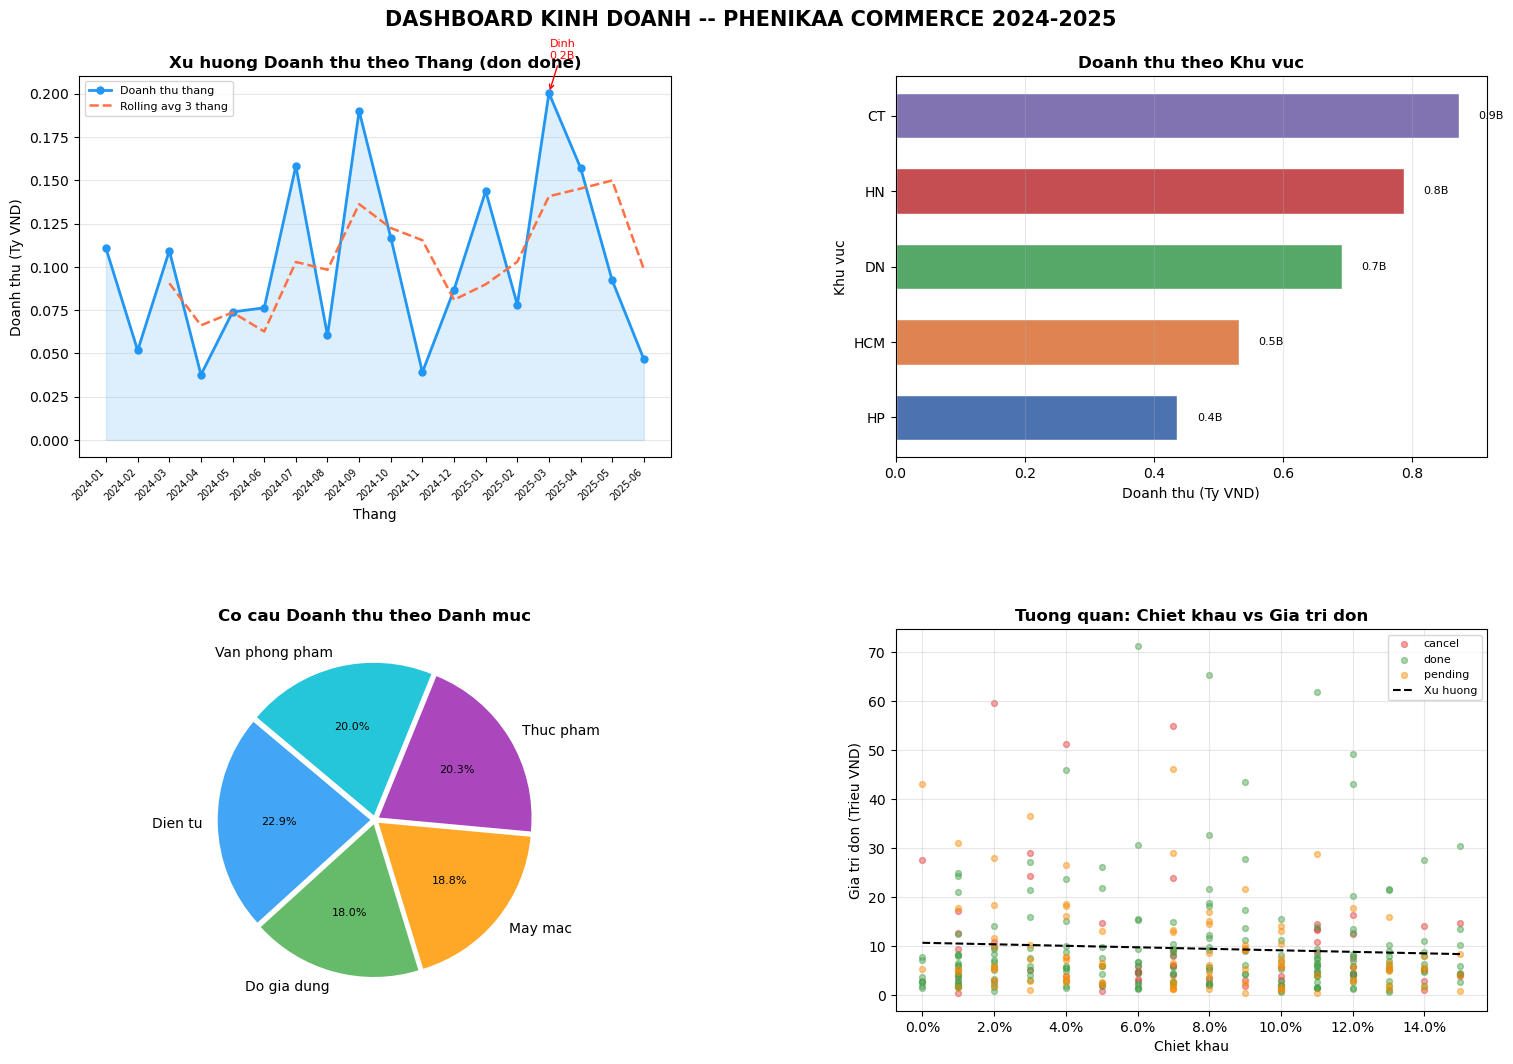

OK Da luu: dashboard_matplotlib.png


In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np

# Chuan bi du lieu
dt_thang_sorted = dt_thang.sort_values("thang")
x_thang      = list(range(len(dt_thang_sorted)))
y_dt         = dt_thang_sorted["doanh_thu"].values / 1e9
y_roll       = dt_thang_sorted["rolling_avg_3"].values / 1e9
labels_thang = [str(t) for t in dt_thang_sorted["thang_str"]]
idx_max      = int(np.argmax(y_dt))

dt_kv = df_orders.groupby("khu_vuc")["gia_tri"].sum().sort_values(ascending=True) / 1e9
dt_dm = df_orders.groupby("danh_muc")["gia_tri"].sum()
x_sc  = df_orders["chiet_khau"].values
y_sc  = df_orders["gia_tri"].values / 1e6

# Tao Figure GridSpec 2x2
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("DASHBOARD KINH DOANH -- PHENIKAA COMMERCE 2024-2025",
             fontsize=15, fontweight="bold", y=0.99)
plt.subplots_adjust(hspace=0.45, wspace=0.38, left=0.08, right=0.96, top=0.93, bottom=0.08)

# [1] Line Chart: Xu huong DT theo thang
ax1.plot(x_thang, y_dt, marker="o", color="#2196F3",
         linewidth=2, markersize=5, label="Doanh thu thang")
ax1.plot(x_thang, y_roll, linestyle="--", color="#FF7043",
         linewidth=1.8, label="Rolling avg 3 thang")
ax1.fill_between(x_thang, y_dt, alpha=0.15, color="#2196F3")
ax1.annotate(f"Dinh\n{y_dt[idx_max]:.1f}B",
             xy=(x_thang[idx_max], y_dt[idx_max]),
             xytext=(x_thang[idx_max] + 0.02, y_dt[idx_max] + 0.02),
             arrowprops=dict(arrowstyle="->", color="red"),
             fontsize=8, color="red")
ax1.set_title("Xu huong Doanh thu theo Thang (don done)", fontweight="bold")
ax1.set_xlabel("Thang"); ax1.set_ylabel("Doanh thu (Ty VND)")
ax1.set_xticks(x_thang)
ax1.set_xticklabels(labels_thang, rotation=45, ha="right", fontsize=7)
ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)

# [2] Horizontal Bar: DT theo khu vuc
colors_kv = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]
bars = ax2.barh(dt_kv.index, dt_kv.values,
                color=colors_kv[:len(dt_kv)], edgecolor="white", height=0.6)
for bar, val in zip(bars, dt_kv.values):
    ax2.text(val + 0.03, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}B", va="center", fontsize=8)
ax2.set_title("Doanh thu theo Khu vuc", fontweight="bold")
ax2.set_xlabel("Doanh thu (Ty VND)"); ax2.set_ylabel("Khu vuc")
ax2.grid(axis="x", alpha=0.3)

# [3] Pie Chart: Co cau danh muc
explode = [0.03] * len(dt_dm)
wedges, texts, autotexts = ax3.pie(
    dt_dm.values, labels=dt_dm.index, autopct="%1.1f%%",
    explode=explode, startangle=140,
    colors=["#42A5F5","#66BB6A","#FFA726","#AB47BC","#26C6DA"])
for at in autotexts:
    at.set_fontsize(8)
ax3.set_title("Co cau Doanh thu theo Danh muc", fontweight="bold")

# [4] Scatter: Chiet khau vs Gia tri don
color_map = {"done":"#43A047","pending":"#FB8C00","cancel":"#E53935"}
for tt, grp in df_orders.groupby("trang_thai"):
    ax4.scatter(grp["chiet_khau"], grp["gia_tri"]/1e6,
                label=tt, alpha=0.45, s=18, color=color_map.get(tt, "gray"))
z = np.polyfit(x_sc, y_sc, 1)
p = np.poly1d(z)
x_line = np.linspace(x_sc.min(), x_sc.max(), 100)
ax4.plot(x_line, p(x_line), "k--", linewidth=1.5, label="Xu huong")
ax4.set_title("Tuong quan: Chiet khau vs Gia tri don", fontweight="bold")
ax4.set_xlabel("Chiet khau"); ax4.set_ylabel("Gia tri don (Trieu VND)")
ax4.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

fig.savefig("dashboard_matplotlib.png", dpi=150, bbox_inches="tight")
plt.show()
print("OK Da luu: dashboard_matplotlib.png")


## 4.2 Dashboard Seaborn (13 điểm)

C:\Users\PC\AppData\Local\Temp\ipykernel_5596\4218105463.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_orders, x="khu_vuc", y="gia_tri",
C:\Users\PC\AppData\Local\Temp\ipykernel_5596\4218105463.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_orders, x="danh_muc", y="gia_tri",


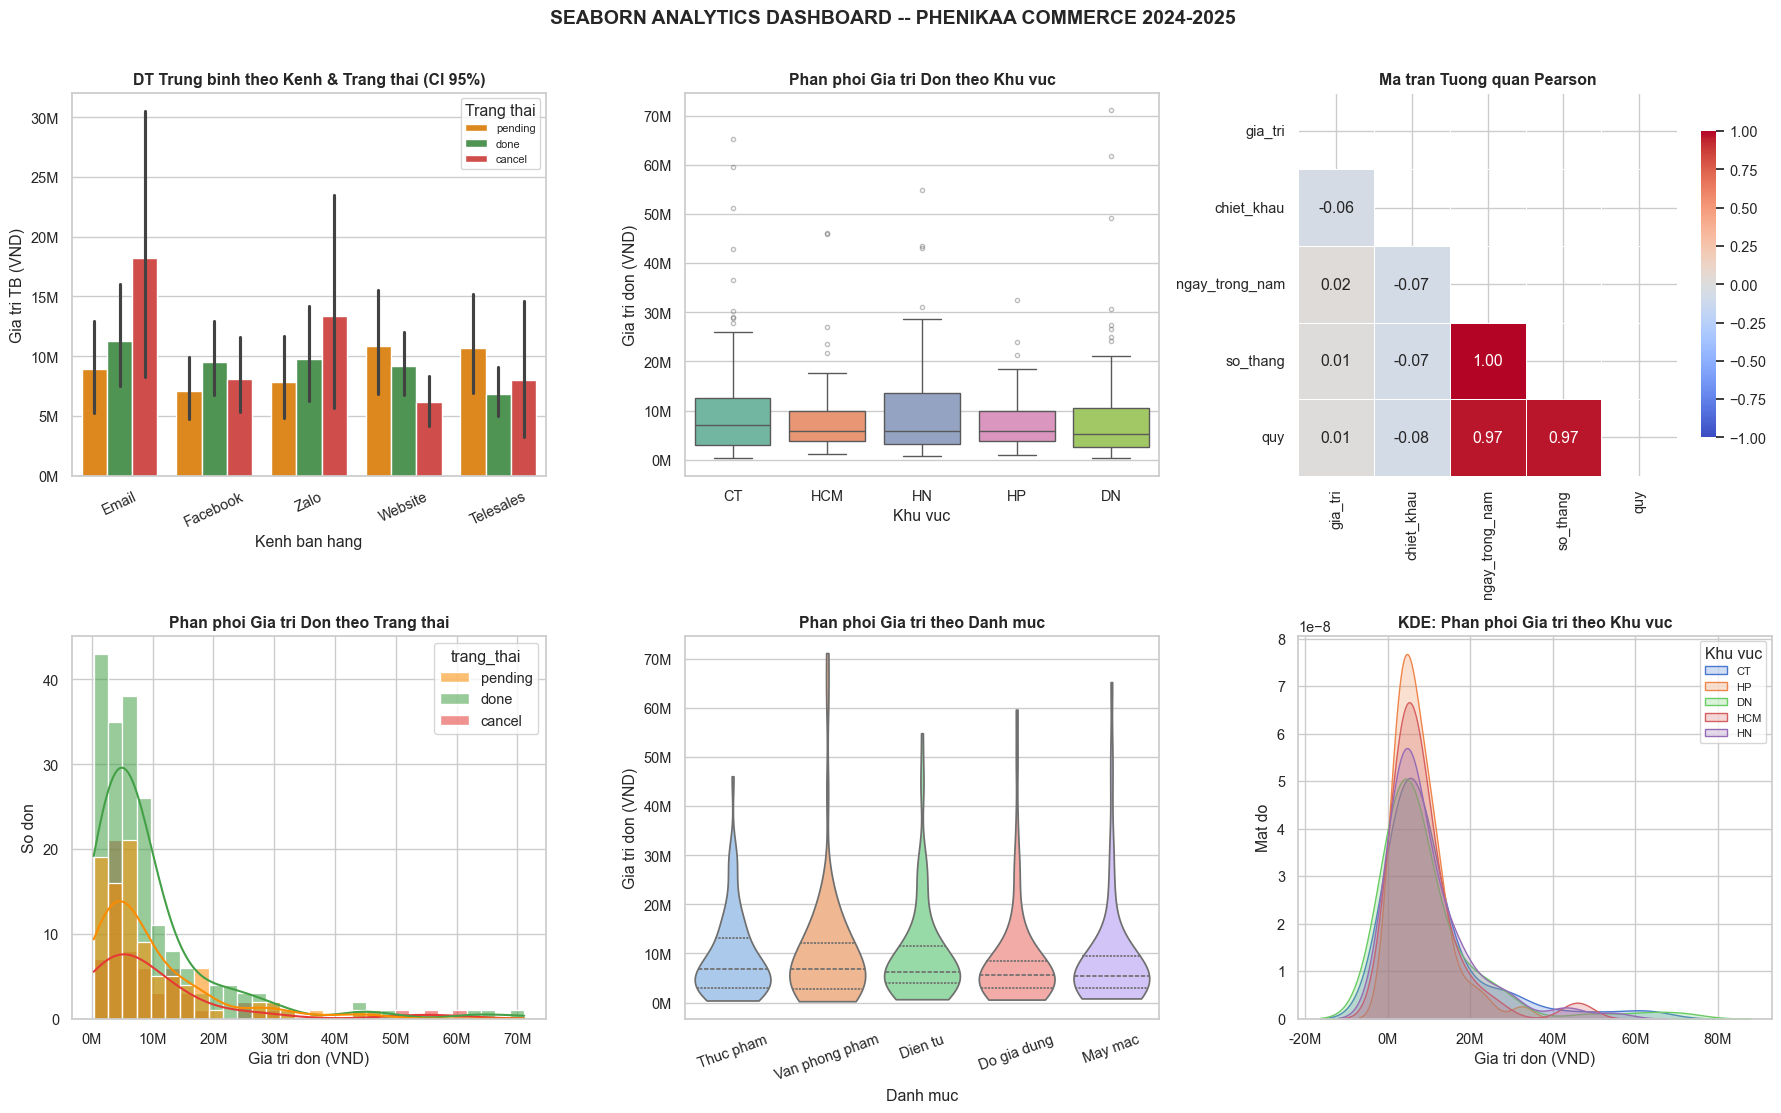

OK Da luu: dashboard_seaborn.png


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)

fig2, axes = plt.subplots(2, 3, figsize=(18, 11))
fig2.suptitle("SEABORN ANALYTICS DASHBOARD -- PHENIKAA COMMERCE 2024-2025",
              fontsize=14, fontweight="bold", y=1.01)

# [1] Barplot voi CI 95%
ax_bar = axes[0, 0]
sns.barplot(data=df_orders, x="kenh_ban", y="gia_tri",
            hue="trang_thai", ax=ax_bar,
            estimator="mean", errorbar=("ci", 95),
            palette={"done":"#43A047","pending":"#FB8C00","cancel":"#E53935"})
ax_bar.set_title("DT Trung binh theo Kenh & Trang thai (CI 95%)", fontweight="bold")
ax_bar.set_xlabel("Kenh ban hang"); ax_bar.set_ylabel("Gia tri TB (VND)")
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_bar.tick_params(axis="x", rotation=25)
ax_bar.legend(title="Trang thai", fontsize=8)

# [2] Boxplot: Phan phoi gia_tri theo khu vuc
ax_box = axes[0, 1]
kv_order = (df_orders.groupby("khu_vuc")["gia_tri"]
            .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=df_orders, x="khu_vuc", y="gia_tri",
            order=kv_order, ax=ax_box, palette="Set2",
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax_box.set_title("Phan phoi Gia tri Don theo Khu vuc", fontweight="bold")
ax_box.set_xlabel("Khu vuc"); ax_box.set_ylabel("Gia tri don (VND)")
ax_box.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

# [3] Heatmap: Ma tran tuong quan
ax_heat = axes[0, 2]
cols_h  = ["gia_tri","chiet_khau","ngay_trong_nam","so_thang","quy"]
corr_h  = df_orders[cols_h].corr()
mask    = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, ax=ax_heat, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, mask=mask,
            linewidths=0.5, cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
ax_heat.set_title("Ma tran Tuong quan Pearson", fontweight="bold")

# [4] Histplot + KDE
ax_hist = axes[1, 0]
sns.histplot(data=df_orders, x="gia_tri", hue="trang_thai",
             kde=True, ax=ax_hist, bins=30, alpha=0.55,
             palette={"done":"#43A047","pending":"#FB8C00","cancel":"#E53935"})
ax_hist.set_title("Phan phoi Gia tri Don theo Trang thai", fontweight="bold")
ax_hist.set_xlabel("Gia tri don (VND)"); ax_hist.set_ylabel("So don")
ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))

# [5] Violinplot: Phan phoi theo danh muc
ax_vio = axes[1, 1]
dm_order = (df_orders.groupby("danh_muc")["gia_tri"]
            .median().sort_values(ascending=False).index.tolist())
sns.violinplot(data=df_orders, x="danh_muc", y="gia_tri",
               order=dm_order, ax=ax_vio, palette="pastel",
               inner="quartile", cut=0)
ax_vio.set_title("Phan phoi Gia tri theo Danh muc", fontweight="bold")
ax_vio.set_xlabel("Danh muc"); ax_vio.set_ylabel("Gia tri don (VND)")
ax_vio.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_vio.tick_params(axis="x", rotation=20)

# [6] KDE plot theo khu vuc
ax_kde = axes[1, 2]
for kv in df_orders["khu_vuc"].unique():
    subset = df_orders[df_orders["khu_vuc"] == kv]["gia_tri"]
    sns.kdeplot(data=subset, ax=ax_kde, label=kv, fill=True, alpha=0.25)
ax_kde.set_title("KDE: Phan phoi Gia tri theo Khu vuc", fontweight="bold")
ax_kde.set_xlabel("Gia tri don (VND)"); ax_kde.set_ylabel("Mat do")
ax_kde.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.0f}M"))
ax_kde.legend(title="Khu vuc", fontsize=8)

fig2.tight_layout()
fig2.savefig("dashboard_seaborn.png", dpi=150, bbox_inches="tight")
plt.show()
print("OK Da luu: dashboard_seaborn.png")


## BONUS: Pairplot phân tích quan hệ đa biến (+2 điểm)

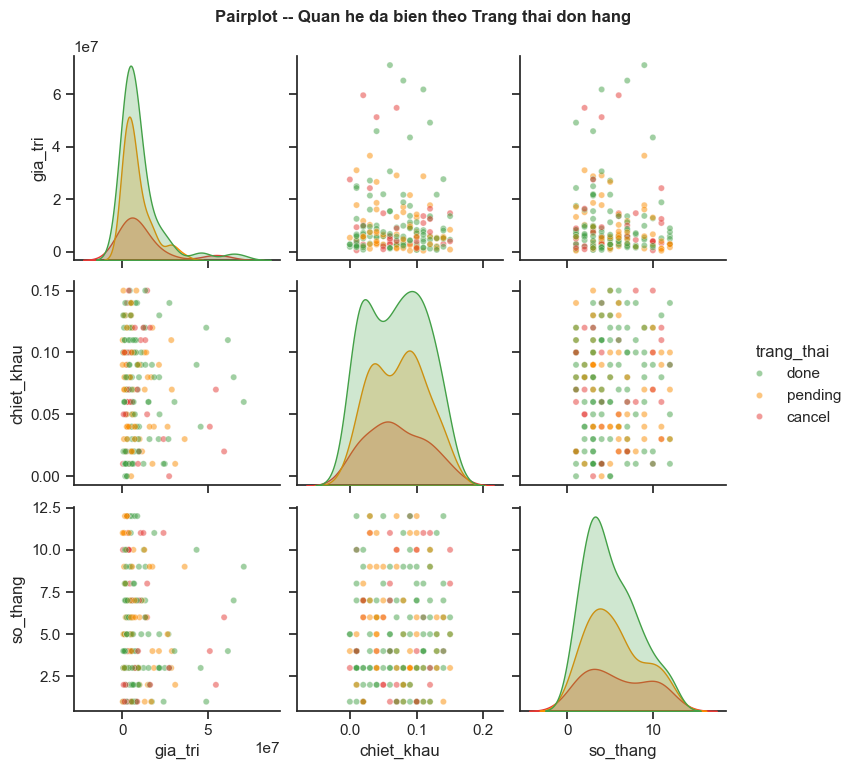

OK Da luu: pairplot_bonus.png  (+2 diem bonus)


In [19]:
# BONUS (+2 diem): Pairplot voi hue phan tich quan he da bien
sns.set_theme(style="ticks")
df_pair = df_orders[["gia_tri","chiet_khau","so_thang","trang_thai"]].sample(200, random_state=42)
pp = sns.pairplot(
    df_pair, hue="trang_thai",
    palette={"done":"#43A047","pending":"#FB8C00","cancel":"#E53935"},
    plot_kws=dict(alpha=0.5, s=20), diag_kind="kde"
)
pp.fig.suptitle("Pairplot -- Quan he da bien theo Trang thai don hang",
                y=1.02, fontsize=12, fontweight="bold")
pp.savefig("pairplot_bonus.png", dpi=120, bbox_inches="tight")
plt.show()
print("OK Da luu: pairplot_bonus.png  (+2 diem bonus)")


---
# PHẦN 5: BÁO CÁO TỔNG KẾT VÀ ĐỀ XUẤT (10 điểm)
**CĐR 2.1** — Thiết kế giải pháp dựa trên phân tích dữ liệu thực tế

## 5.1 Tóm tắt dự án (5 điểm)

In [20]:
# (a) KPI tong quan
tong_dt       = df_orders["gia_tri"].sum()
so_don_done   = (df_orders["trang_thai"] == "done").sum()
so_don_cancel = (df_orders["trang_thai"] == "cancel").sum()
aov           = tong_dt / len(df_orders)
ty_le_huy     = so_don_cancel / len(df_orders) * 100

print("=" * 60)
print("      BAO CAO TONG KET -- PHENIKAA COMMERCE")
print("      Giai doan: 01/2024 - 06/2025")
print("=" * 60)
print()
print("-- (a) KPI TONG QUAN --")
print(f"  Tong doanh thu       : {tong_dt:>20,.0f} VND")
print(f"  Tong so don          : {len(df_orders):>20,}")
print(f"  Don hoan thanh       : {so_don_done:>20,}  ({so_don_done/len(df_orders)*100:.1f}%)")
print(f"  AOV (gia tri TB/don) : {aov:>20,.0f} VND")
print(f"  Ti le huy don        : {ty_le_huy:>19.1f}%")

# (b) Top & Bottom
print()
print("-- (b) DIEM NOI BAT --")
tk_k    = df_orders.groupby("kenh_ban")["gia_tri"].sum().sort_values(ascending=False)
tk_kv_s = df_orders.groupby("khu_vuc")["gia_tri"].sum().sort_values(ascending=False)
thang_but_pha = dt_thang.loc[dt_thang["doanh_thu"].idxmax()]

print(f"  Top 3 kenh hieu qua  : {', '.join(tk_k.head(3).index.tolist())}")
print(f"  Top 3 khu vuc DT cao : {', '.join(tk_kv_s.head(3).index.tolist())}")
print(f"  Kenh kem nhat        : {tk_k.idxmin()} ({tk_k.min():,.0f} VND)")
print(f"  KV DT thap nhat      : {tk_kv_s.idxmin()} ({tk_kv_s.min():,.0f} VND)")
print(f"  Thang but pha nhat   : {thang_but_pha['thang_str']} "
      f"({thang_but_pha['doanh_thu']:,.0f} VND)")

# (c) Van de phat hien
print()
print("-- (c) VAN DE PHAT HIEN --")

huy_kenh = (
    df_orders[df_orders["trang_thai"] == "cancel"]
    .groupby("kenh_ban").size() /
    df_orders.groupby("kenh_ban").size() * 100
).sort_values(ascending=False)

print("  1. Ti le huy theo kenh:")
for k, v in huy_kenh.items():
    flag = "  [!] CAO" if v > ty_le_huy else ""
    print(f"       {k:12s}: {v:.1f}%{flag}")

n_outlier_check = len(df_orders[
    (df_orders["gia_tri"] < p25 - 1.5*iqr) |
    (df_orders["gia_tri"] > p75 + 1.5*iqr)
])
print(f"  2. {n_outlier_check} don hang ngoai le (IQR) -- gia tri bat thuong can kiem tra")
print()
print("=" * 60)


      BAO CAO TONG KET -- PHENIKAA COMMERCE
      Giai doan: 01/2024 - 06/2025

-- (a) KPI TONG QUAN --
  Tong doanh thu       :        3,319,156,000 VND
  Tong so don          :                  350
  Don hoan thanh       :                  194  (55.4%)
  AOV (gia tri TB/don) :            9,483,303 VND
  Ti le huy don        :                17.7%

-- (b) DIEM NOI BAT --
  Top 3 kenh hieu qua  : Website, Facebook, Email
  Top 3 khu vuc DT cao : CT, HN, DN
  Kenh kem nhat        : Telesales (281,286,000 VND)
  KV DT thap nhat      : HP (436,396,000 VND)
  Thang but pha nhat   : 2025-03 (200,377,000 VND)

-- (c) VAN DE PHAT HIEN --
  1. Ti le huy theo kenh:
       Facebook    : 19.8%  [!] CAO
       Zalo        : 18.2%  [!] CAO
       Email       : 17.5%
       Telesales   : 16.7%
       Website     : 16.4%
  2. 32 don hang ngoai le (IQR) -- gia tri bat thuong can kiem tra



## 5.2 Nhận xét và đề xuất cải tiến (5 điểm)

In [21]:
# Tinh chi so cu the de dua vao de xuat
tb_huy        = ty_le_huy
kenh_huy_cao  = huy_kenh.idxmax()
pct_huy_cao   = huy_kenh.max()
kenh_dt_thap  = tk_k.idxmin()
pct_kenh_thap = tk_k.min() / tong_dt * 100
kv_thap       = tk_kv_s.idxmin()
pct_kv_thap   = tk_kv_s.min() / tong_dt * 100

print("=" * 65)
print("   DE XUAT CAI TIEN KINH DOANH -- PHENIKAA COMMERCE")
print("=" * 65)

print()
print(f"-- DE XUAT 1 (Uu tien CAO): Giam ti le huy don kenh {kenh_huy_cao}")
print(f"   Van de  : Kenh {kenh_huy_cao} co ti le huy {pct_huy_cao:.1f}%, cao hon")
print(f"             muc TB he thong {tb_huy:.1f}% ({pct_huy_cao/tb_huy:.1f}x).")
print(f"   Hanh dong: Ra soat quy trinh xac nhan don qua {kenh_huy_cao};")
print(f"             trien khai auto-reminder sau 2h neu chua xac nhan;")
print(f"             goi dien chot don > 10 trieu VND sau 24h.")
print(f"   Muc tieu : Giam ti le huy kenh {kenh_huy_cao} xuong < {tb_huy:.1f}%")
print(f"             trong 60 ngay -- tuong duong them ~{tong_dt*(pct_huy_cao-tb_huy)/100/1e9:.2f} ty VND/ky.")

print()
print(f"-- DE XUAT 2 (Uu tien TRUNG): Tai co cau nguon luc kenh {kenh_dt_thap}")
print(f"   Van de  : Kenh {kenh_dt_thap} chi dong gop {pct_kenh_thap:.1f}% tong DT --")
print(f"             thap nhat trong 5 kenh, khong tuong xung chi phi van hanh.")
print(f"   Hanh dong: Kiem tra chi phi/don kenh {kenh_dt_thap}; neu CAC > AOV x margin,")
print(f"             chuyen 50% ngan sach sang kenh Website (top DT)")
print(f"             va dau tu SEO/SEM de tang don chat luong cao hon.")
print(f"   Muc tieu : Cai thien ROI kenh thap nhat len > 120% trong Q3 2025")
print(f"             hoac hop nhat vao kenh Email de tiet kiem chi phi.")

print()
print(f"-- DE XUAT 3 (Uu tien TRUNG): Phat trien thi truong {kv_thap}")
print(f"   Van de  : Khu vuc {kv_thap} dong gop chi {pct_kv_thap:.1f}% tong DT --")
print(f"             tiem nang thi truong chua duoc khai thac.")
print(f"   Hanh dong: Bo sung 1-2 dai ly khu vuc {kv_thap}; trien khai")
print(f"             chuong trinh uu dai gioi thieu KH moi (referral 3%);")
print(f"             to chuc hoi thao san pham truc tuyen nham den DN vua.")
print(f"   Muc tieu : Tang thi phan {kv_thap} len it nhat {pct_kv_thap*1.5:.1f}% trong 2 quy,")
print(f"             tuong duong them {tong_dt*pct_kv_thap*0.5/100/1e9:.2f} ty VND doanh thu.")

print()
print("=" * 65)


   DE XUAT CAI TIEN KINH DOANH -- PHENIKAA COMMERCE

-- DE XUAT 1 (Uu tien CAO): Giam ti le huy don kenh Facebook
   Van de  : Kenh Facebook co ti le huy 19.8%, cao hon
             muc TB he thong 17.7% (1.1x).
   Hanh dong: Ra soat quy trinh xac nhan don qua Facebook;
             trien khai auto-reminder sau 2h neu chua xac nhan;
             goi dien chot don > 10 trieu VND sau 24h.
   Muc tieu : Giam ti le huy kenh Facebook xuong < 17.7%
             trong 60 ngay -- tuong duong them ~0.07 ty VND/ky.

-- DE XUAT 2 (Uu tien TRUNG): Tai co cau nguon luc kenh Telesales
   Van de  : Kenh Telesales chi dong gop 8.5% tong DT --
             thap nhat trong 5 kenh, khong tuong xung chi phi van hanh.
   Hanh dong: Kiem tra chi phi/don kenh Telesales; neu CAC > AOV x margin,
             chuyen 50% ngan sach sang kenh Website (top DT)
             va dau tu SEO/SEM de tang don chat luong cao hon.
   Muc tieu : Cai thien ROI kenh thap nhat len > 120% trong Q3 2025
             hoac hop nhat

---
## ✅ Hoàn tất Bài tập lớn CSE703185

| Phần | Nội dung | Điểm tối đa |
|------|----------|-------------|
| 1 | Nền tảng Python (List/Dict/Set/Tuple, 4 hàm, Lambda/Filter/Map) | 20 |
| 2 | OOP: KhachHang, KhachHangVIP, SanPham + kiểm thử | 20 |
| 3 | NumPy & Pandas: 350 bản ghi, EDA, groupby, pivot, corr, IQR | 25 |
| 4 | Matplotlib GridSpec dashboard + Seaborn dashboard | 25 |
| 5 | Executive Summary + 3 đề xuất cải tiến gắn số liệu | 10 |
| **Bonus** | Pairplot (+2đ) + Docstring Google Style (+3đ) | **+5** |
| **Tổng** | | **105** |